In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# Carrega os dados do CSV   . Delimiter=',' indica que as colunas são separadas por virgula
# skiprows=2 para pular as duas linhas de cabeçalho/comentário
# usecols para que o código não confunca as pipes | antes dos números, deixando uma coluna vazia
dataset = np.loadtxt("knn_dataset_exercicio_1.csv", delimiter='|', skiprows=2, usecols=(1, 2, 3))

# separa as colunas de características (features) e a coluna de rótulos (labels)
# X_train recebe todas as linhas, mas apenas as duas primeiras colunas (indice 0 e 1)
X_train = dataset[:, :2]

# y_train recebe todas as linhas, mas apenas a última coluna (indice2)
# .astype(int) para garantir que as classes sejam tratadas como inteiros
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos(y_train):")
print(y_train[:5])

Amostra das características (X_train):

Amostra dos rótulos(y_train):
[1 1 1 2 2]


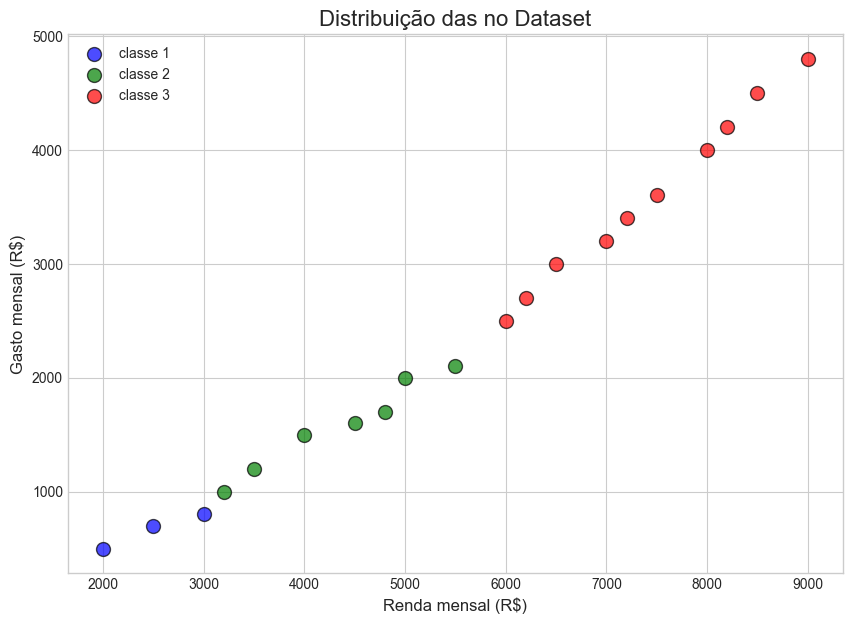

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# plota a classe 1
ax.scatter(X_train[y_train == 1, 0], X_train[y_train ==1, 1],
           c='blue', s=100, edgecolors='k', alpha=0.7, label='classe 1')

# plota a classe 2
ax.scatter(X_train[y_train == 2, 0], X_train[y_train ==2, 1],
           c='green', s=100, edgecolors='k', alpha=0.7, label='classe 2')

# plota os pontos benignos (Classe 1)
ax.scatter(X_train[y_train == 3, 0], X_train[y_train ==3, 1],
           c='red', s=100, edgecolors='k', alpha=0.7, label='classe 3')

ax.set_title('Distribuição das no Dataset', fontsize=16)
ax.set_xlabel('Renda mensal (R$)', fontsize=12)
ax.set_ylabel('Gasto mensal (R$)', fontsize=12)
ax.legend()
plt.show()

In [4]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

In [5]:
def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos proximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena as distancias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # CORREÇÃO AQUI: pega o indice 1 (a classe) de cada tupla 'd'
    vizinhos = [d[1] for d in distancias[:k]]
    return vizinhos

In [6]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritario dos vizinhos"""
    
    # conta a ocorrencia de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)

    # retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

In [7]:
# Exemplo de novo cliente: Renda 4200, Gasto 1400
novo_ponto = np.array([4200.0, 1400.0])
k = 5  # ou 5
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
previsao_final = prever_classificacao(vizinhos_proximos)
print(f"Novo cliente: Renda={novo_ponto[0]}, Gasto={novo_ponto[1]}")
print(f"Valor de k: {k}")
print(f"Classes dos {k} vizinhos mais próximos: {vizinhos_proximos}")
print("----------------------------------------------------------")
print(f"--> Previsão final: Classe {previsao_final}")

Novo cliente: Renda=4200.0, Gasto=1400.0
Valor de k: 5
Classes dos 5 vizinhos mais próximos: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
----------------------------------------------------------
--> Previsão final: Classe 2


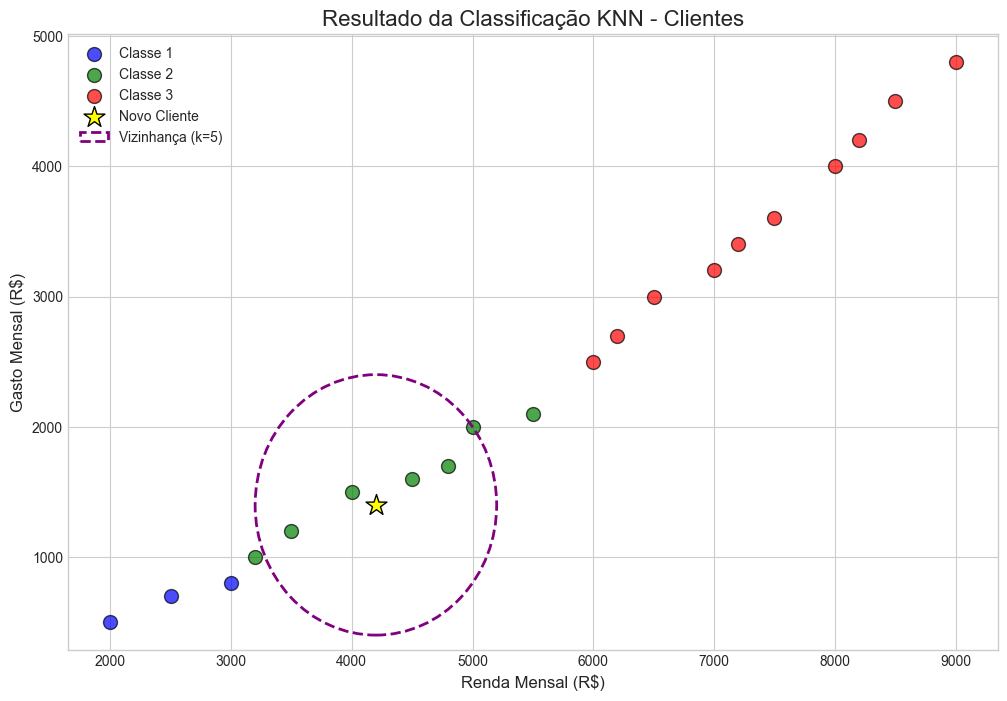

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plota os dados de treino com as 3 classes
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', s=100, edgecolor='k', alpha=0.7, label='Classe 1')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1], c='green', s=100, edgecolor='k', alpha=0.7, label='Classe 2')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1], c='red', s=100, edgecolor='k', alpha=0.7, label='Classe 3')

# Plota o novo ponto
ax.scatter(novo_ponto[0], novo_ponto[1], c='yellow', s=250, edgecolor='k', marker='*', label='Novo Cliente')

# Destaque para o círculo de vizinhos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_ponto) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]
distancia_maxima = calcular_distancia_euclidiana(novo_ponto, pontos_vizinhos[-1])

circulo = plt.Circle(novo_ponto, distancia_maxima, color='purple', fill=False, linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

ax.set_title('Resultado da Classificação KNN - Clientes', fontsize=16)
ax.set_xlabel('Renda Mensal (R$)', fontsize=12)
ax.set_ylabel('Gasto Mensal (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()


### Exercício 1 - Quesitos e Respostas

**a) O KNN conseguiu separar bem os clientes em grupos de consumo (baixo, médio e alto)?**  
> **Sim.** No dataset fornecido, os dados apresentam uma clara correlação positiva e linear entre `Renda_Mensal` e `Gasto_Mensal`. As classes estão distribuídas em faixas bem definidas e sem sobreposição (*overlap*):
> - **Classe 1 (Baixo consumo):** Renda até R$ 3.000 e Gasto até R$ 800.
> - **Classe 2 (Médio consumo):** Renda entre R$ 3.200 e R$ 5.500 e Gasto entre R$ 1.000 e R$ 2.100.
> - **Classe 3 (Alto consumo):** Renda a partir de R$ 6.000 e Gasto a partir de R$ 2.500.
> 
> Por estarem agrupados em regiões contínuas e distantes entre si, o KNN consegue traçar fronteiras de decisão nítidas e classificar com alta taxa de acerto.

---

**b) Há casos em que clientes com renda alta, mas gasto baixo, podem ser classificados incorretamente? O que isso indica sobre a estratégia de segmentação?**  
> **Sim, podem ser classificados incorretamente.**  
> 1. **Motivo técnico (Escala e Distância Euclidiana):** A escala da `Renda_Mensal` varia em milhares (de 2.000 a 9.000), enquanto o `Gasto_Mensal` tem valores menores. Sem normalização/padronização dos atributos, a variável com maior magnitude numérica (Renda) domina o cálculo da distância euclidiana. Assim, um cliente com Renda R$ 7.000 e Gasto R$ 600 ficaria numericamente mais próximo de quem tem Renda alta (Classe 3), mesmo gastando pouco como a Classe 1.
> 2. **O que indica sobre a segmentação:** Indica que classificar "grupo de consumo no supermercado" olhando apenas para a renda pode levar a falsas conclusões. Clientes de alta renda podem ser poupadores ou realizar compras em outros estabelecimentos. Para um supermercado, a variável `Gasto_Mensal` (comportamento de compra real) é muito mais determinante para consumo do que a renda declarada. Além disso, reforça a importância da normalização dos dados antes de aplicar o KNN.

---

**c) Como a escolha do valor de k influencia na fronteira entre os grupos?**  
> - **Valores baixos de $k$ (ex: $k=1$ ou $k=3$):** A fronteira de decisão fica mais complexa, recortada e sensível a cada ponto individual (alta variância). Se houver ruído ou clientes atípicos (*outliers*), eles influenciarão diretamente a classificação de seus vizinhos mais próximos (risco de *overfitting*).
> - **Valores intermediários de $k$ (ex: $k=3$ a $k=5$):** Para o tamanho dessa amostra (20 exemplos), $k=3$ ou $k=5$ oferece um bom equilíbrio, suavizando as transições sem misturar classes distantes.
> - **Valores altos de $k$ (ex: $k \ge 11$):** A fronteira fica excessivamente simplificada e generalista (alto viés / *underfitting*). Como a Classe 3 possui mais amostras no dataset (10 amostras) do que a Classe 1 (apenas 3 amostras), um $k$ excessivamente grande faz com que a classe majoritária domine as votações, prejudicando a classificação dos clientes de menor consumo.
